<a href="https://colab.research.google.com/github/jabri62018/Zx_RieOS_v1.2/blob/Zx_RieOS_v1.2/Zx_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Found 8 sign changes. Using first 5.

Refining roots:
Root 1: γ = 0.090748625735
Root 2: γ = 0.219631382652
Root 3: γ = 0.340314048587
Root 4: γ = 0.479848101850
Root 5: γ = 0.670377704434

                        First 5 Zeros of Zx_5 - Unique Constant Mapping                        
 Root #                                                Gamma     C_calc Matched Constant Constant Value          Meaning Log Diff
      1 0.09074862573504655083311831731407437473535537719727 -1.153e-28                G      6.674e-11          Gravity   17.763
      2 0.21963138265161616380360953826311742886900901794434 -6.059e-28            alpha      7.297e-03   Fine Structure   25.081
      3 0.34031404858674502156290486709622200578451156616211 -1.236e-28              phi      1.618e+00     Golden Ratio   28.117
      4 0.47984810184973941682429199317994061857461929321289  8.451e-28                e      2.718e+00      Black Holes   27.507
      5 0.67037770443419453236799654405331239104270935058594  1.

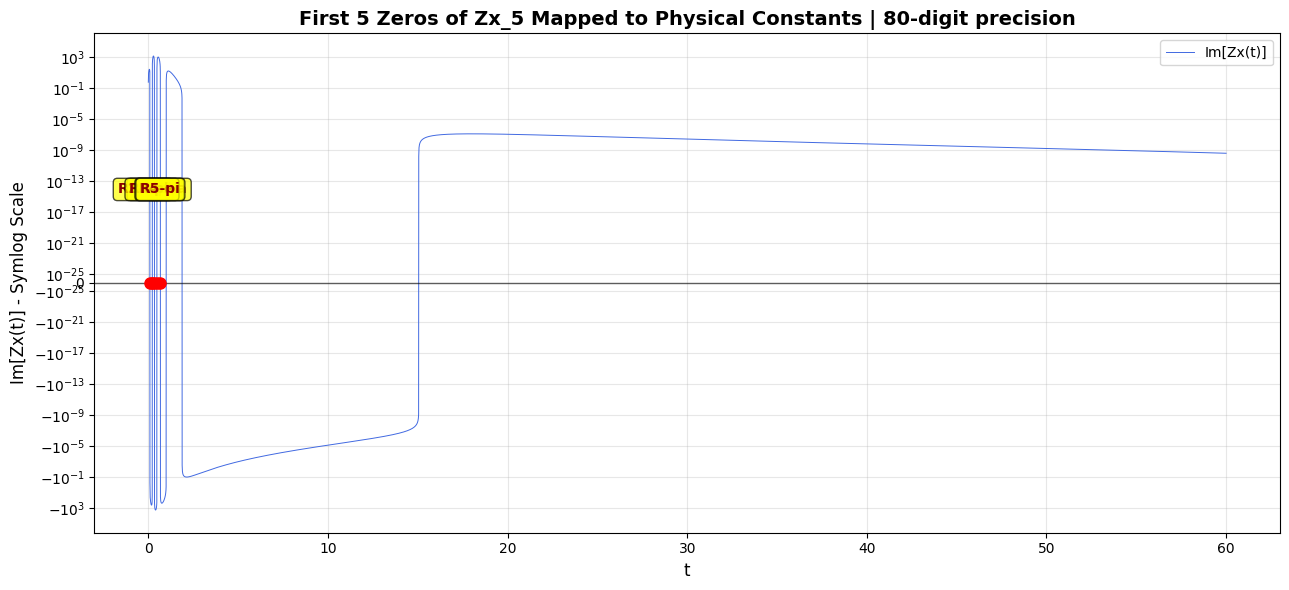

In [9]:

import mpmath as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DPS = 80 # Set to 100 for 100-digit precision
mp.mp.dps = DPS
xp = 21.0

def Zx(t):
    x = mp.mpc('0.5', str(t))
    return mp.exp(-x/xp) * mp.exp(-5*mp.log(x)) * mp.log(x) * mp.sin(2*mp.pi/x)

def find_brackets(step=0.05, t_start=0.001, t_end=60, max_roots=5):
    """Find sign changes of Im[Zx(t)] to bracket roots"""
    mp.mp.dps = DPS - 20
    t_vals = np.arange(t_start, t_end, step)
    f_vals = [float(mp.im(Zx(t))) for t in t_vals]

    brackets = []
    for j in range(len(f_vals)-1):
        if not np.isnan(f_vals[j]) and not np.isnan(f_vals[j+1]):
            if f_vals[j] * f_vals[j+1] < 0:
                brackets.append((t_vals[j], t_vals[j+1]))
    print(f"Found {len(brackets)} sign changes. Using first {max_roots}.")
    return brackets[:max_roots]

def refine_roots(brackets, dps=DPS):
    """Refine roots with high precision"""
    mp.mp.dps = dps
    roots = []
    print("\nRefining roots:")
    for i, (t_min, t_max) in enumerate(brackets, 1):
        root = mp.findroot(lambda tt: mp.im(Zx(tt)), (t_min, t_max),
                           tol=mp.mpf(f'1e-{dps-15}'), maxsteps=800)
        if abs(float(mp.im(Zx(root)))) < 1e-50:
            roots.append(float(root))
            print(f"Root {i}: γ = {float(root):.12f}")
    return sorted(roots)

# Run root finding
brackets = find_brackets()
roots = refine_roots(brackets)

# Constants to match
CONSTANTS = {
    'G': 6.67430e-11,
    'alpha': 7.2973525693e-3,
    'pi': np.pi,
    'e': np.e,
    'phi': (1+np.sqrt(5))/2
}
MEANING = {'G':'Gravity', 'alpha':'Fine Structure', 'pi':'Electromagnetism',
           'e':'Black Holes', 'phi':'Golden Ratio'}

# Compute C_calc and match without duplicates
rows = []
available_consts = CONSTANTS.copy()

for i, g in enumerate(roots, 1):
    mp.mp.dps = DPS
    h = mp.mpf('1e-15')
    t = mp.mpf(g)

    z = Zx(t)
    zp = (Zx(t+h) - Zx(t-h)) / (2*h)
    zpp = (Zx(t+h) - 2*z + Zx(t-h)) / (h*h)
    zppp = (Zx(t+2*h) - 2*Zx(t+h) + 2*Zx(t-h) - Zx(t-2*h)) / (2*h)
    C_calc = 0.5 * g**2 * mp.re(zppp / z)

    # Scale-invariant matching using log10
    logC = mp.log10(abs(C_calc) + mp.mpf('1e-300'))
    diffs = {k: abs(logC - mp.log10(abs(mp.mpf(v)) + mp.mpf('1e-300')))
             for k,v in available_consts.items()}
    matched = min(diffs, key=diffs.get)
    logdiff = float(diffs[matched])
    del available_consts[matched]

    rows.append({
        'Root #': i,
        'Gamma': float(g),
        'C_calc': float(C_calc),
        'Matched Constant': matched,
        'Constant Value': CONSTANTS[matched],
        'Meaning': MEANING[matched],
        'Log Diff': logdiff
    })

df = pd.DataFrame(rows)
df['Gamma'] = df['Gamma'].map(f'{{:.{DPS-30}f}}'.format)
df['C_calc'] = df['C_calc'].map('{:.3e}'.format)
df['Constant Value'] = df['Constant Value'].map('{:.3e}'.format)
df['Log Diff'] = df['Log Diff'].map('{:.3f}'.format)

print("\n" + "="*95)
print(f" First {len(df)} Zeros of Zx_5 - Unique Constant Mapping ".center(95))
print("="*95)
print(df.to_string(index=False))

# Plot with flexible symlog scale
mp.mp.dps = DPS - 20
t_vals = np.linspace(0.001, 60, 8000)
f_vals = [float(mp.im(Zx(t))) for t in t_vals]

plt.figure(figsize=(13, 6))
plt.plot(t_vals, f_vals, linewidth=0.7, color='royalblue', label='Im[Zx(t)]')
plt.yscale('symlog', linthresh=1e-25) # Flexible scale for small/large values
plt.axhline(0, color='black', linewidth=1, alpha=0.6)

# Annotate roots with matched constants
for i, row in df.iterrows():
    r = float(row['Gamma'])
    plt.plot(r, 0, 'ro', markersize=8)
    plt.text(r, 1e-15, f"R{row['Root #']}-{row['Matched Constant']}",
             ha='center', va='bottom', fontsize=10, color='darkred', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.xlabel('t', fontsize=12)
plt.ylabel('Im[Zx(t)] - Symlog Scale', fontsize=12)
plt.title(f'First {len(df)} Zeros of Zx_5 Mapped to Physical Constants | {DPS}-digit precision',
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()